In [1]:
from importlib.resources import files, as_file
from nsbutils.plotting import plot_surf
from neuromodes import EigenSolver
from neuromodes.io import fetch_surf, fetch_map
import numpy as np
from neuromodes.eigen import unparcellate
from nsbutils.utils import unmask

# Load cortical surface mesh
surf, _ = fetch_surf()

In [2]:
# load schaefer100
parc = np.loadtxt('C:/Users/ipop0003/neuromodes/docs/tutorials/tutorial_data/fsLR_32k_Schaefer100-lh.txt', dtype=int)
# mask = parc != 0  # mask of non-medial wall vertices
# parc = parc[mask]  # remove medial wall vertices
# n_parcs = len(np.unique(parc))

In [5]:
# create random parcellated data
rng = np.random.default_rng(0)
data = rng.uniform(size=50)

In [6]:
# unparcellate without interpolation
data_unparc = unparcellate(data, parc=parc)
data_unparc_unmask = unmask(data_unparc, mask=mask)
data_unparc.shape

C:\Users\ipop0003\neuromodes\neuromodes\eigen.py:813: UserWarning: Number of observations in data matches number of parcels excluding 0. Proceeding with removal of 0 parcel.
  if not (data.shape[0] == n_parcels - 1 and np.any(parc_ids == 0)):


ValueError: matmul: dimension mismatch with signature (n,k=51),(k=50,1?)->(n,1?)

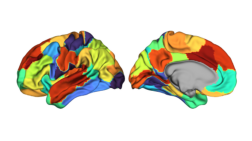

In [12]:
surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'
plot_surf(surfpath, data_unparc_unmask)

P is unchanged: True
Correlation between parcellated data: 0.9629800443926726


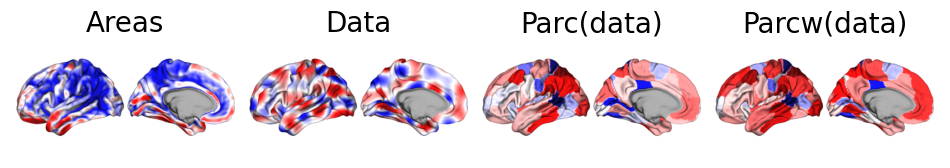

In [53]:
# Make a sparse parcellation matrix P (n_verts x n_parcs) such that P.T @ data = data_parc
from scipy.sparse import csc_matrix
n_verts = len(parc)

P = csc_matrix((np.ones(n_verts), (np.arange(n_verts), parc)), shape=(n_verts, n_parcs))

# get vertex areas from 30k mass matrix
#solver = EigenSolver(surf, mask=mask).solve(100)
vert_areas = np.asarray(np.sum(solver.mass, axis=0))[0]
parc_areas = P.T @ vert_areas

# use area-weighted parcellation matrix to preserve total area
P_vp = P.multiply(vert_areas[:, np.newaxis] / parc_areas)

# check for in-place modification of P
print('P is unchanged:', np.all(P.data == 1))

# use area-weighted parcellation matrix, assuming uniform vertex areas
P_p = P.multiply(1 / P.sum(axis=0))

# use to parcellate data
data = solver.emodes[:, -1]
data_unparc = unparcellate(P_p.T @ data, parc=parc)
data_unparcw = unparcellate(P_vp.T @ data, parc=parc)
corr = np.corrcoef(P_p.T @ data, P_vp.T @ data)
print('Correlation between parcellated data:', corr[0, 1])


all_data = np.stack([vert_areas, data, data_unparc, data_unparcw], axis=1)

# plot all maps
plot_surf(surfpath, unmask(all_data, mask=mask), labels=['Areas', 'Data', 'Parc(data)', 'Parcw(data)'], cmap='seismic')



In [33]:
P_p

<COOrdinate sparse matrix of dtype 'float64'
	with 29300 stored elements and shape (29300, 50)>